In [1]:
# Import libraries 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    f1_score,
    classification_report
)

# Task 1

## Task 1.1

In [2]:
# Import dataset 
CC = pd.read_csv("CC_Default.csv")
CC.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [6]:
# Check the number of observations and variables
CC.shape

(30000, 25)

## Task 1.2

In [7]:
CC.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [8]:
# Check for missing values 
CC.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [9]:
# Convert variables to categorical 
cat_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

for col in cat_cols:
    CC[col] = CC[col].astype("category")


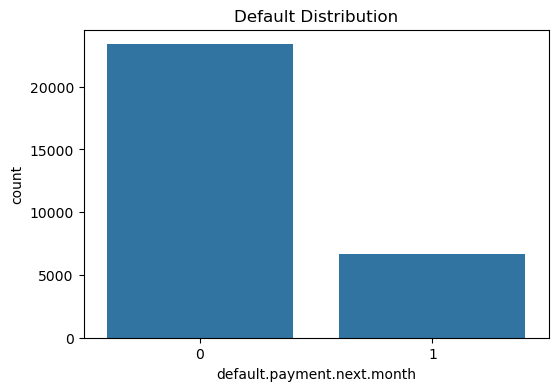

In [12]:
# Plot the default distribution 
plt.figure(figsize=(6,4))

sns.countplot(
    x="default.payment.next.month",
    data=CC
)

plt.title("Default Distribution")
plt.show()

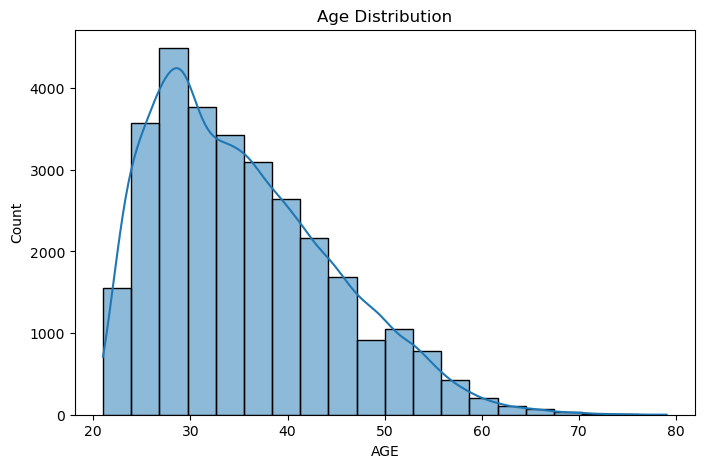

In [14]:
# Plot the age distribution 
plt.figure(figsize=(8,5))

sns.histplot(
    CC["AGE"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

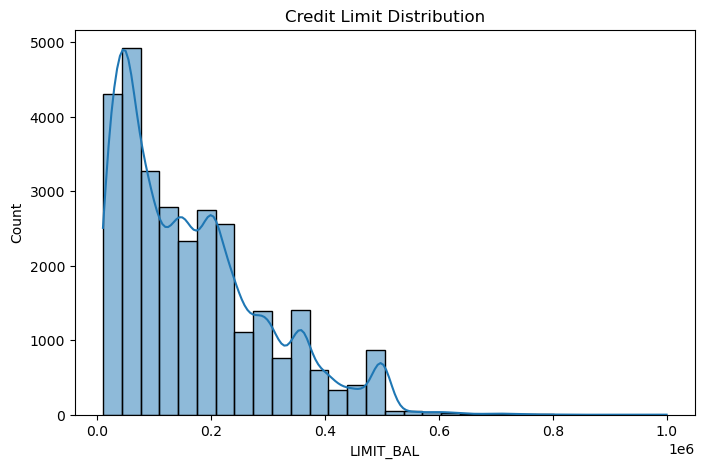

In [15]:
# Plot the credit limit distribution 
plt.figure(figsize=(8,5))

sns.histplot(
    CC["LIMIT_BAL"],
    bins=30,
    kde=True
)

plt.title("Credit Limit Distribution")
plt.show()

## Task 1.3

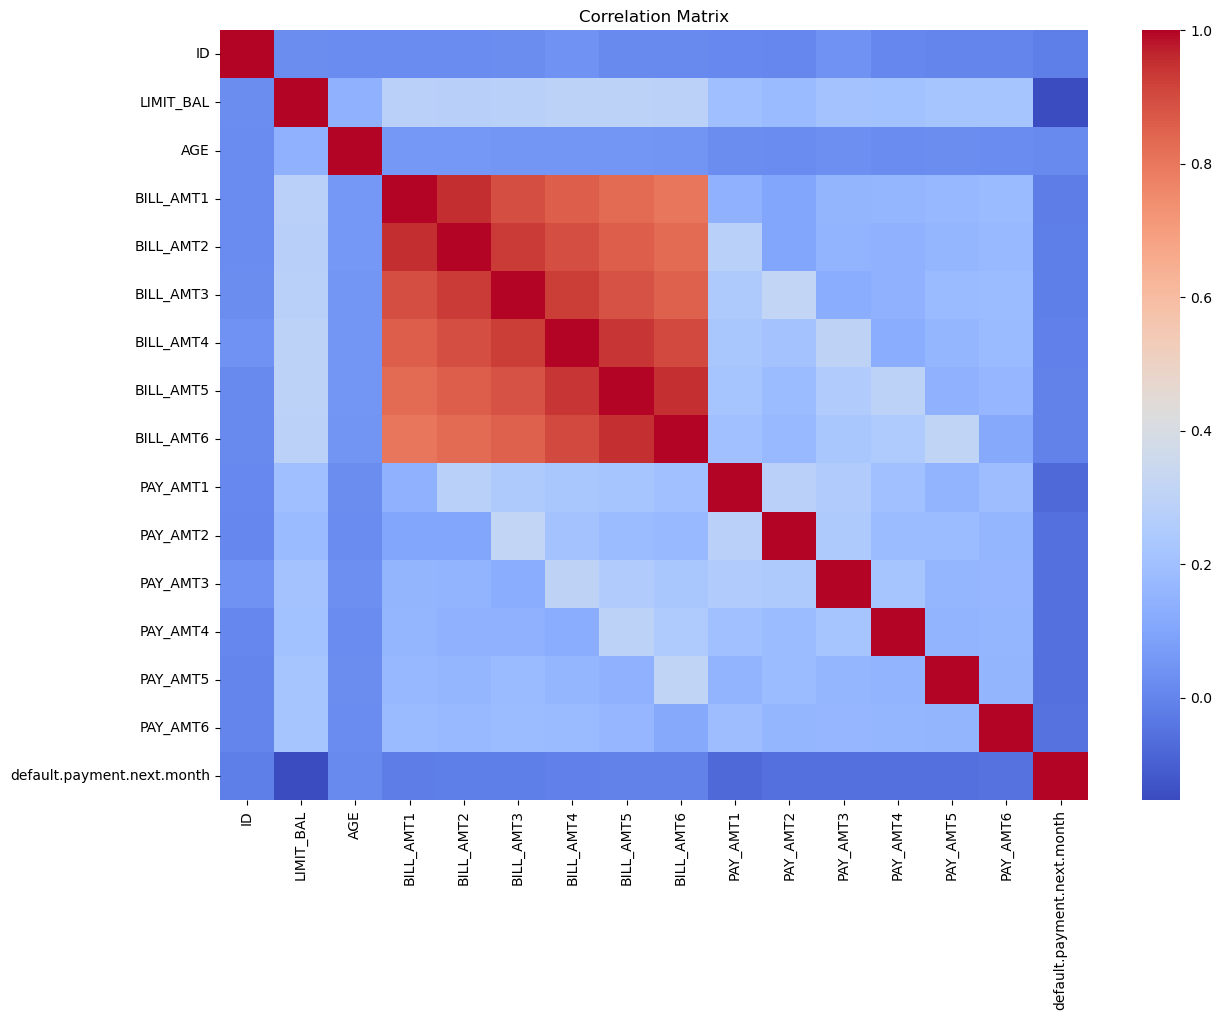

In [16]:
# Plot the correlation heatmap 
plt.figure(figsize=(14,10))

corr = CC.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

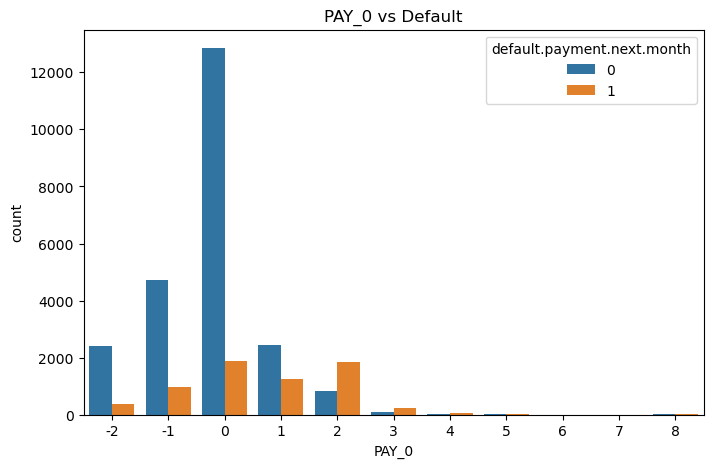

In [20]:
# Show the relationship between PAY_0 and Default
plt.figure(figsize=(8,5))

sns.countplot(
    x="PAY_0",
    hue="default.payment.next.month",
    data=CC
)

plt.title("PAY_0 vs Default")
plt.show()

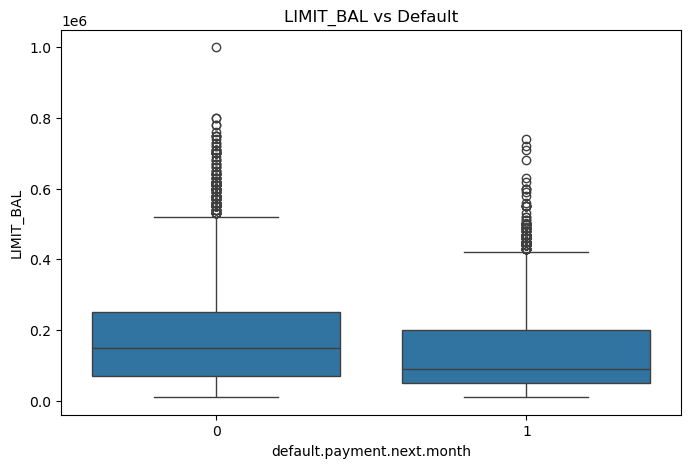

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='default.payment.next.month',
    y='LIMIT_BAL',
    data=CC
)

plt.title("LIMIT_BAL vs Default")
plt.show()

## Task 1.4

Based on the exploratory analysis, repayment status appears to be the strongest indicator of whether a customer will default on their next credit card payment. From the PAY_0 vs Default plot, customers with repayment delays of 2 months or more show a much higher proportion of defaults compared to customers who paid on time or had no repayment delays. This suggests that recent repayment behaviour is a key predictor of future default risk.

The LIMIT_BAL vs Default boxplot shows that customers who default generally have lower credit limits compared to customers who do not default. The median credit limit for defaulters is lower, indicating that customers with smaller available credit may face greater financial difficulty and are more likely to miss future payments. However, there is substantial overlap between the two groups, suggesting that credit limit alone is not sufficient to identify defaulters.

The correlation heatmap reveals strong positive correlations among the BILL_AMT variables (BILL_AMT1 to BILL_AMT6). This indicates that customers with high bill amounts in one month tend to have high bill amounts in subsequent months. Similarly, the PAY_AMT variables show moderate positive correlations with one another. These relationships suggest potential multicollinearity among the bill amount variables, which should be considered when building predictive models.

The target variable, default.payment.next.month, shows relatively weak linear correlations with individual numerical variables. This suggests that no single variable is sufficient to explain default behaviour. Instead, default is likely influenced by a combination of factors, particularly repayment history, credit usage, and payment behaviour.

Overall, repayment status variables, especially PAY_0, appear to be the most useful predictors for identifying customers who are likely to default on their next credit card payment.

# Task 2

## Task 2.1

In [21]:
# import train.csv 
train = pd.read_csv("Train.csv")

train.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default
0,2,120000,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
1,4,50000,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
2,5,50000,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
3,6,50000,1,1,2,37,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
4,7,500000,1,1,2,29,0,0,0,0,...,542653.0,483003.0,473944.0,55000.0,40000.0,38000.0,20239.0,13750.0,13770.0,0


In [ ]:
# Convert to variables to categorical 
for col in cat_cols:
    train[col] = train[col].astype("category")

## Task 2.2

In [24]:
# Separate X and y dataset 
X_train = train.drop(
    'Default',
    axis=1
)

y_train = train[
    'Default'
]

# Convert catergorical variables to dummy variables 
X_train = pd.get_dummies(
    X_train,
    drop_first=True
)

# Fit the logistic regression model 
log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=10000,
    random_state=1
)

log_model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,1
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


## Task 2.3 

In [25]:
# Remove variables causing multicollinearity 
train_reduced = train.drop(
    columns=[
        'BILL_AMT2',
        'BILL_AMT3',
        'BILL_AMT4',
        'BILL_AMT5',
        'BILL_AMT6'
    ]
)

### Variables Removed to Reduce Multicollinearity

The correlation heatmap showed strong positive correlations among:

- BILL_AMT1
- BILL_AMT2
- BILL_AMT3
- BILL_AMT4
- BILL_AMT5
- BILL_AMT6

To reduce multicollinearity, the following variables were removed:

- BILL_AMT2
- BILL_AMT3
- BILL_AMT4
- BILL_AMT5
- BILL_AMT6

BILL_AMT1 was retained as a representative bill amount variable.

# Task 2.4

In [33]:
# Load test.csv
test = pd.read_csv("Test.csv")

test.head() 

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default
0,5170,140000,2,2,2,26,0,0,2,0,...,125046,46364.0,83460,125000,6.0,4578.0,1427.0,87179.0,26291.0,1
1,22727,90000,2,1,2,31,1,-2,-2,-2,...,0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0
2,4884,150000,2,1,2,32,2,2,2,0,...,123954,131543.0,134319,6000,3000.0,4600.0,9800.0,5100.0,5000.0,1
3,7142,30000,2,2,2,21,-2,-2,-2,-2,...,4311,1551.0,0,780,3260.0,4311.0,1551.0,0.0,0.0,0
4,19043,70000,2,2,2,23,2,2,2,0,...,18013,19315.0,19859,2850,0.0,1400.0,1600.0,1000.0,0.0,1


In [34]:
categorical_cols = [
    'SEX',
    'EDUCATION',
    'MARRIAGE',
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6'
]

# Apply data preprocessing 
for col in categorical_cols:
    test[col] = test[col].astype('category')

test = test.drop(
    columns=[
        'BILL_AMT2',
        'BILL_AMT3',
        'BILL_AMT4',
        'BILL_AMT5',
        'BILL_AMT6'
    ]
)

# Create the x and y dataset 
X_test = test.drop(
    'Default',
    axis=1
)

y_test = test[
    'Default'
]

# Create dummy variables 
X_test = pd.get_dummies(
    X_test,
    drop_first=True
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Predict 
pred_lr = log_model.predict(X_test)


## Task 2.5

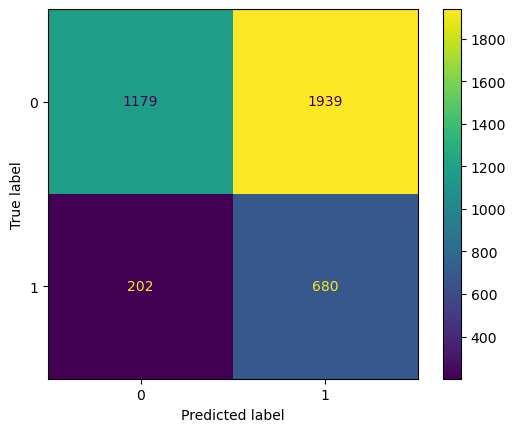

In [35]:
# Plot confusion matrix 
cm = confusion_matrix(y_test, pred_lr)

ConfusionMatrixDisplay(cm).plot()

plt.show()

## Task 2.6

In [36]:
# Print out the accuracy, precision and F1 score 
print("Accuracy :", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("F1 Score :", f1_score(y_test, pred_lr))

Accuracy : 0.46475
Precision: 0.2596410843833524
F1 Score : 0.3884604398743216


### Logistic Regression Model Evaluation 
The logistic regression model achieved an ***accuracy of 46.48%***, a ***precision of 25.96%***, and an ***F1-score of 38.85%*** on the test dataset.

The accuracy indicates that the model correctly classified approximately 46% of customers. This is relatively low, suggesting that the model has difficulty distinguishing between customers who will default and those who will not.

The precision score of 25.96% means that when the model predicts a customer will default, only about 26% of those predictions are correct. This indicates a *relatively high number of false positive predictions*.

The F1-score of 38.85% reflects the balance between precision and recall. Since the dataset is imbalanced, the F1-score is a more informative measure than accuracy alone. The moderate F1-score suggests that the model is able to identify some defaulters but still has limited predictive performance.

Overall, the logistic regression model provides a baseline for predicting credit card defaults. However, the relatively low accuracy, precision, and F1-score indicate that more advanced machine learning models such as Random Forest, Support Vector Machine (SVM), or Artificial Neural Networks (ANN) may provide better predictive performance.


# Task 3

## Task 3.1

In [37]:
# Fit the random forest model 
rf_model = RandomForestClassifier(
    random_state=1,
    n_estimators=500,
    max_depth=3,
    max_features=3
)

rf_model.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Task 3.2

In [38]:
# Predict 
pred_rf = rf_model.predict(X_test)

# Obtain the F1 score and accuracy 
acc_rf = accuracy_score(y_test, pred_rf)
f1_rf = f1_score(y_test, pred_rf)

print("Accuracy :", acc_rf)
print("F1 Score :", f1_rf)

Accuracy : 0.7795
F1 Score : 0.0


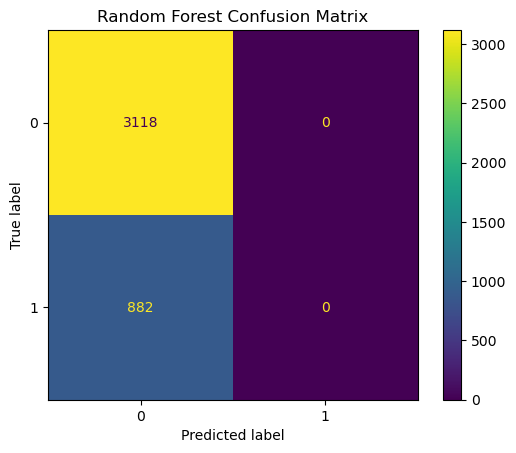

In [39]:
# Plot the confusion matrix 
cm_rf = confusion_matrix(y_test, pred_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

### Random Forest Model Evaluation

The Random Forest model achieved an ***accuracy of 77.95%*** and an ***F1-score of 0.00*** on the test dataset.

Although the accuracy appears high, the confusion matrix shows that the model classified every customer as a non-defaulter (Class 0). As a result, the model correctly identified 3,118 non-default customers but failed to identify any of the 882 customers who actually defaulted.

The F1-score of 0.00 indicates that the model was unable to detect the minority class. This demonstrates that accuracy alone is not an appropriate measure for evaluating performance on an imbalanced dataset. Despite achieving a higher accuracy than the Logistic Regression model, the Random Forest model performed poorly in identifying customers who were likely to default.

Compared with Logistic Regression, the Random Forest model achieved higher accuracy but a lower F1-score. Therefore, Logistic Regression performed better in detecting default customers, while Random Forest was heavily biased towards predicting the majority class.


# Task 4

## Task 4.1

In [48]:
from sklearn.preprocessing import StandardScaler

# Scale the data 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit SVM model 
svm_model = SVC(
    gamma=0.025,
    C=3
)

svm_model.fit(
    X_train_scaled,
    y_train
)

,C,3
,kernel,'rbf'
,degree,3
,gamma,0.025
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Task 4.2

In [49]:
# Predict 
pred_svm = svm_model.predict(
    X_test_scaled
)

# Calculate F1 score and accuracy 
acc_svm = accuracy_score(y_test, pred_svm)
f1_svm = f1_score(y_test, pred_svm)

print("Accuracy :", acc_svm)
print("F1 Score :", f1_svm)

Accuracy : 0.7795
F1 Score : 0.0


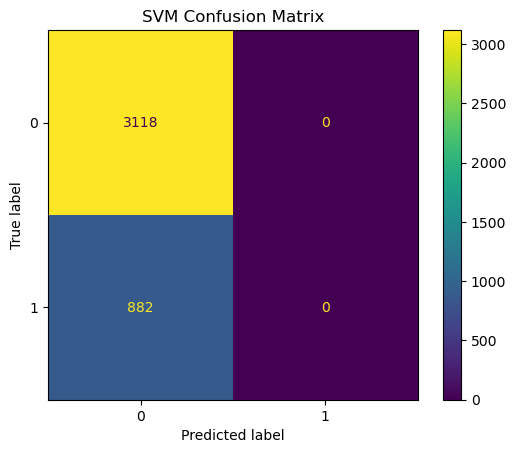

In [50]:
# Plot confusion matrix 
cm_svm = confusion_matrix(y_test, pred_svm)

ConfusionMatrixDisplay(
    confusion_matrix=cm_svm
).plot()

plt.title("SVM Confusion Matrix")
plt.show()

### SVM Evaluation

The Support Vector Machine (SVM) model achieved an ***accuracy of 77.95%*** and an ***F1-score of 0.00*** on the test dataset.

The confusion matrix shows that the model classified all customers as non-defaulters (Class 0). It correctly identified 3,118 customers who did not default but failed to identify any of the 882 customers who actually defaulted.

Although the model achieved a relatively high accuracy, this result is mainly due to the ***imbalance*** in the dataset, where the majority of customers belong to the non-default class. The F1-score of 0.00 indicates that the model was unable to identify any default cases and therefore has poor performance in detecting the minority class.

Overall, the SVM model is not suitable for this credit card default prediction task because it failed to identify customers who are likely to default despite achieving a high accuracy.

# Task 5

## Task 5.1 & 5.2

In [51]:
from sklearn.neural_network import MLPClassifier

# Fit the ANN Model 
ann = MLPClassifier(
    hidden_layer_sizes=(8,8),
    activation='relu',
    solver='adam',
    batch_size=15,
    max_iter=100,
    random_state=1
)

# Train 
ann.fit(
    X_train_scaled,
    y_train
)

# Predict
pred_ann = ann.predict(
    X_test_scaled
)

## Task 5.3

In [52]:
# Show the accuracy and F1 score 
acc_ann = accuracy_score(
    y_test,
    pred_ann
)

f1_ann = f1_score(
    y_test,
    pred_ann
)

print("Accuracy :", acc_ann)
print("F1 Score :", f1_ann)

Accuracy : 0.7795
F1 Score : 0.004514672686230248


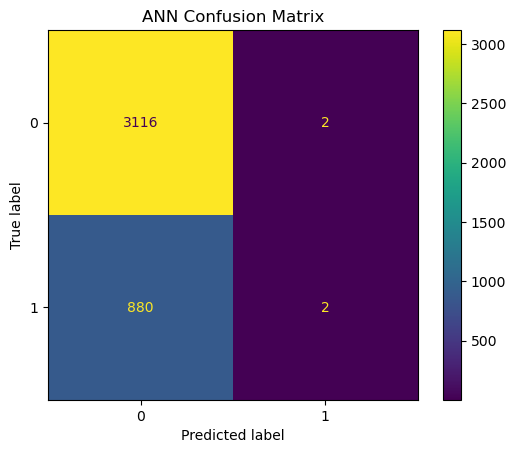

In [53]:
# Plot the confusion matrix 
cm_ann = confusion_matrix(
    y_test,
    pred_ann
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_ann
).plot()

plt.title("ANN Confusion Matrix")
plt.show()

### ANN Evaluation

The Artificial Neural Network (ANN) model achieved an ***accuracy of 77.95%*** and an ***F1-score of 0.0045*** on the test dataset.

The confusion matrix shows that the ANN correctly identified 3,116 non-default customers and 2 default customers. However, the model failed to identify the remaining 880 customers who actually defaulted.

Compared to the Random Forest and SVM models, the ANN demonstrated a ***slight improvement*** because it was able to detect a small number of default cases. This resulted in a non-zero F1-score. However, the F1-score remains extremely low, indicating that the model has ***very limited ability*** to identify customers who are likely to default.

Although the ANN achieved a relatively high accuracy, this is primarily due to the large proportion of non-default customers in the dataset. Therefore, the ANN is not an effective model for predicting credit card defaults based on the current evaluation results.


# Task 6

Based on the evaluation metrics, ***Logistic Regression*** would be selected as the final model for predicting credit card defaults.

Although Logistic Regression achieved the lowest accuracy among the four models, it produced the highest F1-score. Since the dataset is ***imbalanced***, accuracy alone is not a reliable performance measure because a model can achieve high accuracy by simply predicting the majority class. This was observed in the Random Forest and SVM models, which achieved an accuracy of 77.95% but failed to identify any default customers, resulting in an F1-score of 0.00.

The ANN model showed a slight improvement by correctly identifying a small number of default customers, resulting in an F1-score of 0.0045. However, its performance was still significantly lower than that of Logistic Regression.

The Logistic Regression model was the ***only model*** that effectively identified default customers and achieved a substantially higher F1-score of 0.3885. As the primary objective of this task is to identify customers who are likely to default on their credit card payments, the ability to correctly classify the minority class is more important than achieving a high overall accuracy.

Therefore, Logistic Regression is the preferred model because it provides the best balance between identifying default customers and overall predictive performance on the test dataset.